# Volumes & isosurfaces

Two ways to look at a 3-D scalar cube (a NetCDF/datacube `(level, lat, lon)` field):

- **`volume`** ray-casts the whole field with an opacity transfer function (depth-cued cloud).
- **`isosurface`** extracts shells of constant value.

Ray-cast volumes read best on a **dark background**, so we set one; `volume` also disables the theme's anti-aliasing internally (SSAA washes ray-casts out).

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title=''):
    """Screenshot a scene off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]          # exclude the bottom colour-bar strip
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} of the scene differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


## A synthetic field

In [2]:
axis = np.linspace(-3, 3, 32)
X, Y, Z = np.meshgrid(axis, axis, axis, indexing='ij')
cube = np.exp(-(X**2 + Y**2 + Z**2)) + 0.6 * np.exp(-((X - 1.6)**2 + (Y + 1.1)**2 + (Z - 0.4)**2))
print('cube shape (nz, ny, nx):', cube.shape, '| range:', round(float(cube.min()), 2), '->', round(float(cube.max()), 2))

cube shape (nz, ny, nx): (32, 32, 32) | range: 0.0 -> 0.99


## Volume ray-cast

`opacity` is a transfer function — a named ramp (`'sigmoid'`, `'linear'`), a scalar, or an array mapped across the data range. Compare two:

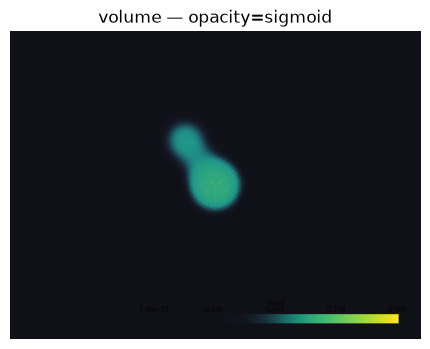

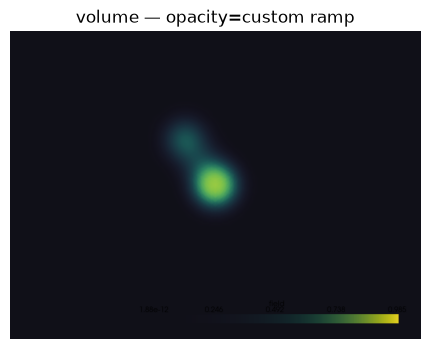

In [3]:
for opacity in ('sigmoid', [0.0, 0.02, 0.08, 0.2, 0.5, 0.9]):
    scene = Scene3D(off_screen=True)
    scene.plotter.set_background('#101018')
    scene.volume(cube, cmap='viridis', opacity=opacity)
    show(scene, f'volume — opacity={opacity if isinstance(opacity, str) else "custom ramp"}')
    scene.close()

## Isosurfaces — shells of constant value

Pass explicit iso-values (or `None` to let PyVista choose). Each shell is coloured by the field.

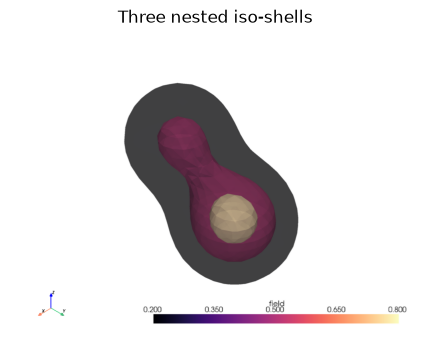

In [4]:
scene = Scene3D(off_screen=True)
scene.isosurface(cube, isosurfaces=[0.2, 0.5, 0.8], cmap='magma', opacity=0.5)
scene.plotter.add_axes()
show(scene, 'Three nested iso-shells')
scene.close()

## Axis convention

A cube indexed `(nz, ny, nx)` = `(level/time, lat, lon)` is laid out so **lon → world X, lat → world Y, level → world Z**. A pyramids `DatasetCollection` (its `.values` stack) is accepted directly (duck-typed) wherever a cube is.